# CNN-based multiclass classifier

### Description

Experiment 1: ModelCNNExp1 baseline training

In this experiment, we conducted baseline training for ModelCNNExp1.

The model was trained with no regularisation layers, no data augmentation for 100 epochs with batch size of 16.

Adamax was used as optimiser, categorial_crossentropy was used as loss function. The training employed cosine decay learning rate as learning scheduler.

In [1]:

# ============
## TIMESTAMP @ 2024-11-07T16:34:02

"""
Experiment Code: CNNExp1_baseline
Model: ModelCNNExp1
Pretrained weights: None
Training type: Training all layers.
Output layers: Default
Regularizer layer: None
Data augmentation: Rescale
Optimizer: Adamax
LearningRate Scheduler: Consine decay
LearningRate Scheduler opt: 0.9, 0.1
epochs: 100
batchsize: 16
"""
# Import necessary libs

import os, io
import datetime
import time
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import logging
import random
import string
# These lib should be placed at the same level at the notebook
import dev_configuration
import dev_dataprocesses
import itertools

2024-12-16 13:08:23.572035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Configuration
The model is configured with no regularised layers, and input normalisation is the only data preprocessing technique applied (for all train, val, and test data). The optimiser is Adamax, with a loss function of categorical_crossentropy, accuracy metrics, and a learning rate scheduler of Cosine decay. The initial LR was 0.001, the decay steps ratio was 0.9, and the alpha was 0.1. The model was fully trained for 100 epochs with a batch size of 16.



In [3]:
randomState_value = 2024

# Dataset configuration
datasets  = ['chest_xray_small', 'chest-xray-full', 'sport-balls']
dataset_name = 'sport-balls'
dataset_original_path = f"./datasets/{dataset_name}/"
test_split_value = 0.2 # split ratio of test from the given data source
val_split_value = 0.3 # split ratio of validation from the given data source
# keras datagenerators configuration
default_xcol_value = 'filepath'
default_ycol_value = 'label'
isShuffle = True

# Debug flags
# legacy flags
isDebug = False # Normal run
isVerbose = True
is_config_exp = False # Disable model archs definition list
# Image size configuration
# legacy
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
# Model configuration
# Learning configuration
model_loss_opt = 'categorical_crossentropy'
learning_rate = 0.001
# learning cosine decay rate
decay_rate = 0.9
decay_alpha_value = 0.1

# default setting for long run
enableEarlyStopping = False
enableEarlyStopping_threshold = 10
epochs = 200
batch_size = 32 # GPU RAM should be at least 24GB
if isDebug:
    # Debug run
    epochs = 10
    batch_size = 16
else:
    # Normal run
    epochs = 100
    batch_size = 16 # Run on small gpu portion
# for transfer learning/finetuning
pretrained_weights = 'imagenet' # Pretrained weights
frozen_weights = False # True: Freeze all base layers. False: otherwise.
# For regulariser layers
kernel_l_value = 0.001
act_l_value = 0.001
drop_out_value_1 = 0.5
drop_out_value_2 = 0.3
drop_out_value_3 = 0.1
models_archs = ['ModelCNNExp1', 'ModelCNNExp2', 'ModelCNNExp3', 'ModelCNNExp4']

Configuration for data augmentation: In this experiment, data normalisation will be carried out in data augmentation process. It is also the only data manipulation.

In [4]:
# Logging and artifacts configuration
# Generate unique exp string
digits = random.choices(string.digits, k=2)
letters = random.choices(string.ascii_uppercase, k=9)
uniq_sample = f"".join(random.sample(digits + letters, 9))

# Setting up folders and logging
exp_base_dir = f"./experiments/"
model_sel = 'ModelCNNExp1'
# configurations for output layers after base-layer
config_output_arc = 'config_1'

# Exp2: No augmenation at all
            # 'rescale': None, # Remember to set None if model is EfficientNet
            # 'rotation_range': 0, # To disable: Set 0
            # 'width_shift_range': 0, # to disable: set 0
            # 'height_shift_range': 0, # to disable: set 0
            # 'zoom_range': 0, # to disable: set 0
            # 'horizontal_flip': False, # to disable: set False
            # 'vertical_flip': False, # to disbale: set False
augmentation_opts = {
            'rescale': 1.0/255.0, # Remember to set None if model is EfficientNet
            'rotation_range': 0, # To disable: Set 0
            'width_shift_range': 0, # to disable: set 0
            'height_shift_range': 0, # to disable: set 0
            'zoom_range': 0, # to disable: set 0
            'horizontal_flip': False, # to disable: set False
            'vertical_flip': False, # to disbale: set False
        }
if model_sel == 'EfficientNetB3':
    augmentation_opts['rescale'] = None

#augmentation_options = f"rescale width_shift_range height_shift_range zoom_range horizontal_flip=True vertical_flip=True"
augmentation_options = f"".join([f"{key}_{augmentation_opts[key]}_" for key in augmentation_opts.keys()])

# other_options = (f"_no_pool_in_base_{config_output_arc}_activity_reg_{act_l_value}_kernel_reg_{kernel_l_value}_dropout_0.3_0.3"
#                  f"\nlearning rate decay: Adamax, "
#                  f"\n decay_rate_{decay_rate}_alpha_{decay_alpha_value}")
other_options = (f"_default_{config_output_arc}_activity_reg_o_kernel_reg_no_dropout_no"
                 f"\nlearning rate decay: Adamax, "
                 f"\n decay_rate_{decay_rate}_alpha_{decay_alpha_value}")


In [5]:
## Preparation

In [6]:
current_datestamp = datetime.datetime.now().strftime("%Y%m%d")
exp_folder = f"{model_sel}-{current_datestamp}_{uniq_sample}"

logs_text_dir = os.path.join(exp_base_dir, exp_folder, "logs")
checkpoints_dir = os.path.join(exp_base_dir, exp_folder, "checkpoints")

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.log"

if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir, exist_ok=True)

if not os.path.exists(logs_text_dir):
    os.makedirs(logs_text_dir, exist_ok=True)

# Create a logger
logger = logging.getLogger('my_logger')
logger.setLevel(logging.DEBUG)

# Create a formatter to define the log format
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# Create a file handler to write logs to a file
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Create a stream handler to print logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)  # You can set the desired log level for console output
console_handler.setFormatter(formatter)

# Add the handlers to the logger
logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info(f"Datetime: {current_timestamp}"
            f"\n Setup all folders and files:"
            f"\n Unique expname: {uniq_sample}"
            f"\n exp_folder: {exp_folder}"
            f"\n -logs_text_dir dir: {logs_text_dir}"
            f"\n -checkpoints_dir : {checkpoints_dir}")


2024-12-16 13:08:26,178 - INFO - Datetime: 20241216-130826
 Setup all folders and files:
 Unique expname: V8RJZNCNG
 exp_folder: ModelCNNExp1-20241216_V8RJZNCNG
 -logs_text_dir dir: ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/logs
 -checkpoints_dir : ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/checkpoints


In [7]:
## Helpers function

In [8]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Oranges,
                          figname='figname.png'):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized Confusion Matrix')
    else:
        print('Confusion Matrix, Without Normalization')
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(fig_name)

def get_model_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_string = stream.getvalue()
    stream.close()
    return summary_string

class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        logs['learning_rate'] = float(tf.keras.backend.get_value(lr))

In [9]:
# Generate data for training

In [10]:
## Data preparation

In [11]:
loaded_datasets = dev_dataprocesses.load_dataset(preconfigured_dataset=dataset_name)
# Load train, val, test data from data_generators.
train_data, val_data, test_data = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts
)

Processing ./datasets/sport-balls
Processing test set
Processing train set
 processes completed
 3

 Label: train 
Length is : 7328
Sample head: 
                                             filepath              label
0  ./datasets/sport-balls/train/american_football...  american_football
1  ./datasets/sport-balls/train/american_football...  american_football
2  ./datasets/sport-balls/train/american_football...  american_football
3  ./datasets/sport-balls/train/american_football...  american_football
4  ./datasets/sport-balls/train/american_football...  american_football
Sample shape: 
 (7328, 2)
Value counts: 
 label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           34

In [12]:
## Models definition

In [13]:
# Model arch library
# Customized model arch


In [14]:
logger.info(f"Training {model_sel} model  with new configuration")

if model_sel == 'VGG16':
    base_model = keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'VGG19':
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'EfficientNetB3':
    base_model = keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        # pooling='max'
    )
# elif model_sel == 'ModelCNNExp1':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp2':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp3':
#     base_model = ModelCnnExp3
# elif model_sel == 'ModelCNNExp4':
#     base_model = ModelCnnExp4
else:
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )

# if model_sel == 'ModelCNNExp1' or model_sel == 'ModelCNNExp2':
if model_sel == 'ModelCNNExp1':
    logger.info(f"Training {model_sel} model  from scratch")
    model_new = keras.models.Sequential([
        # base_model,
        keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=img_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(3, 3)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),

        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPool2D(pool_size=(2, 2)),
        
        ## TIMESTAMP @ 2024-12-13T17:52:43
        ## author: phuocddat
        ## start        
        # CNNExp1_baseline
        keras.layers.Flatten(),
        keras.layers.Dense(1024, activation='relu'),        
        # keras.layers.Dropout(drop_out_value_2), # medium dropout
        keras.layers.Dense(512, activation='relu',
                           #kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                           #activity_regularizer=keras.regularizers.l1(l=act_l_value)
                          ),
        #keras.layers.Dropout(drop_out_value_2), # medium dropout
        ## end --

        # Add regularizers layers to reduce overfitting
        #keras.layers.Flatten(),
        #keras.layers.Dense(1024, activation='relu'),
        
        #keras.layers.Dropout(drop_out_value_2), # medium dropout
        #keras.layers.Dense(512, activation='relu',
                           # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                           # activity_regularizer=keras.regularizers.l1(l=act_l_value)),
        #keras.layers.Dropout(drop_out_value_2), # medium dropout
        ## end --
        keras.layers.Dense(15, activation='softmax')
    ])
##
## Removed other types of model archs which are not as efficient as the ModelCNNEXp1
## ====
elif model_sel == 'EfficientNetB3':
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")

    # Freeze pretrained weight from base_model layers.
    ## TIMESTAMP @ 2024-12-15T16:45:03
    ## author: phuocddat
    ## start
    # Disable trainable setting - default
    # base_model.trainable = False
    ## end --

    logger.info(f"Processing {model_sel} with {config_output_arc} for output block")
    if config_output_arc == 'config_1':
        model_new = keras.models.Sequential([
            base_model,
            # Config 1
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_2':
        model_new = keras.models.Sequential([
            base_model,
            # Config 2
            ## TIMESTAMP @ 2024-12-12T10:38:52
            ## author: phuocddat
            ## start
            ## end --
            keras.layers.BatchNormalization(),
            keras.layers.Dense(256,
                               # kernel_regularizer=keras.regularizers.l2(0.001),
                               # activity_regularizer=keras.regularizers.l1(0.001),
                               activation='relu', ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout - 0.3
            keras.layers.Dense(15, activation="softmax")
        ])
    elif config_output_arc == 'config_3':
        model_new = keras.models.Sequential([
            base_model,
            # Config 3
            # Add regularizers to reduce overfitting
            keras.layers.Dense(512, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout - 0.5
            keras.layers.Dense(15, activation='softmax')
            ## end --
        ])
    elif config_output_arc == 'config_4':
        model_new = keras.models.Sequential([
            base_model,
            # Config 4
            # Add regularizes to reduce overfitting
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            keras.layers.Dense(512, activation='relu',
                               #kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               #activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_5':
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
    else:
        logger.info(f"Not implemented {config_output_arc}")
        logger.info(f"Using one of drafting version below")
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
else:
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")
    # Freeze pretrained weight from base_model layers.
    # base_model.trainable = not frozen_weights
    model_new = keras.models.Sequential([
        base_model,
        # Config 1
        keras.layers.Flatten(),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(15, activation='softmax')
    ])


2024-12-16 13:08:26,334 - INFO - Training ModelCNNExp1 model  with new configuration
2024-12-16 13:08:26.632761: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22066 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:22:00.0, compute capability: 8.9
2024-12-16 13:08:27,492 - INFO - Training ModelCNNExp1 model  from scratch
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [15]:
## Learning strategies

In [16]:
total_steps = len(train_data) * epochs
decay_steps = total_steps * decay_rate
logger.info(f"Total steps: {total_steps}"
      f"\n_decay steps: {decay_steps}")

cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    alpha=decay_alpha_value
)

2024-12-16 13:08:27,575 - INFO - Total steps: 32100
_decay steps: 28890.0


In [17]:
## Compile and fit

In [18]:
current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
exp_save_name = (f"{current_timestamp}___"
                 f"model_{model_sel}_{config_output_arc}_{pretrained_weights}_frozen_"
                 f"Adamax_bs_{batch_size}_frozen_{str(frozen_weights)}_cosine__aug")
checkpoint_path = f"{exp_save_name}.keras"
logger.info(f"epochs {dev_configuration.epochs}"
            f"\n batch size = {batch_size}"
            f"\n other options: {other_options} "
            f"\n augmentation: {augmentation_options}"
            f"\n Checkpoint: {checkpoint_path}")

my_callbacks = [
    # keras.callbacks.EarlyStopping(patience=enableEarlyStopping_threshold) if enableEarlyStopping else None,
    LearningRateLogger(),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]
# Exp model training

2024-12-16 13:08:27,584 - INFO - epochs 200
 batch size = 16
 other options: _default_config_1_activity_reg_o_kernel_reg_no_dropout_no
learning rate decay: Adamax, 
 decay_rate_0.9_alpha_0.1 
 augmentation: rescale_0.00392156862745098_rotation_range_0_width_shift_range_0_height_shift_range_0_zoom_range_0_horizontal_flip_False_vertical_flip_False_
 Checkpoint: 20241216-130827___model_ModelCNNExp1_config_1_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug.keras


In [19]:
model_new.compile(optimizer=tf.optimizers.Adamax(learning_rate=cosine_decay_scheduler),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
# model_summary_string = get_model_summary(model_new)
# logger.info(model_summary_string)
print(f"Model summary:")
model_new.summary()
start_time = time.time()

training_exper_model_eff = model_new.fit(train_data,
                                         epochs=epochs,
                                         validation_data=val_data,
                                         verbose=1,
                                         callbacks=my_callbacks,
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time} seconds")

Model summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 73, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    18,875,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,159,503 (99.79 MB)

 Trainable params: 26,155,663 (99.78 MB)

...

I0000 00:00:1734354518.797519   19812 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


318/321 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1346 - loss: 5.9302  

I0000 00:00:1734354548.182583   20365 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_192', 4 bytes spill stores, 4 bytes spill loads



321/321 ━━━━━━━━━━━━━━━━━━━━ 43s 100ms/step - accuracy: 0.1350 - loss: 5.9038 - val_accuracy: 0.0960 - val_loss: 3.0696 - learning_rate: 9.9973e-04
Epoch 2/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.2722 - loss: 2.3340 - val_accuracy: 0.2392 - val_loss: 2.3948 - learning_rate: 9.9890e-04
Epoch 3/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.3187 - loss: 2.1617 - val_accuracy: 0.2847 - val_loss: 2.4954 - learning_rate: 9.9753e-04
Epoch 4/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.3630 - loss: 2.0240 - val_accuracy: 0.2974 - val_loss: 2.3573 - learning_rate: 9.9562e-04
Epoch 5/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.3968 - loss: 1.9055 - val_accuracy: 0.3574 - val_loss: 2.1812 - learning_rate: 9.9316e-04
Epoch 6/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.4426 - loss: 1.7396 - val_accuracy: 0.3215 - val_loss: 2.2877 - learning_rate: 9.9017e-04
Epoch 7/100
321/321 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - 

2024-12-16 13:43:27,529 - INFO - Training finished in 2099.9168059825897 seconds


In [20]:
## Evaluating
# Full Evaluate model
ts_length = len(test_data)
test_batch_size = max(
    sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_new.evaluate(train_data, steps=test_steps, verbose=1)
valid_score = model_new.evaluate(val_data, steps=test_steps, verbose=1)
test_score = model_new.evaluate(test_data, steps=test_steps, verbose=1)
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 4.6194e-07 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4375 - loss: 5.6832
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7083 - loss: 2.8128
Train Loss:  4.1723194499354577e-07
Train Accuracy:  1.0
--------------------
Validation Loss:  5.6273298263549805
Validation Accuracy:  0.4375
--------------------
Test Loss:  3.917297601699829
Test Accuracy:  0.65625


The test accuracy metric was quite high in compared to accuracy figure for validation data. There are serveral reasons: (1) there may be a gap between the data distribution between the validation and the test set, (2) there may be a data drift between the validation and test datasets, (3) the model was not well generalised and/or heavily overfitted

In [21]:
## Plots and results

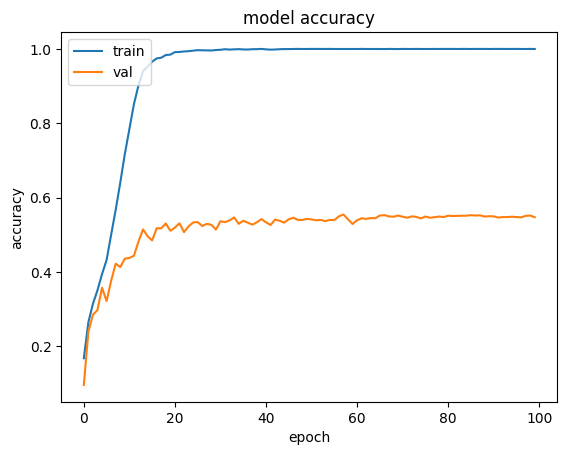

2024-12-16 13:43:28,576 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/logs/20241216-134328_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_8_acc_tr1.0_va0.4375_te0.65625_accuracy_plot.png


<Figure size 640x480 with 0 Axes>

In [22]:
metrics_string = f"acc_tr{train_score[1]}_va{valid_score[1]}_te{test_score[1]}"

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_"
            f"{metrics_string}_"
            f"accuracy_plot.png")

plt.plot(training_exper_model_eff.history['accuracy'])
plt.plot(training_exper_model_eff.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

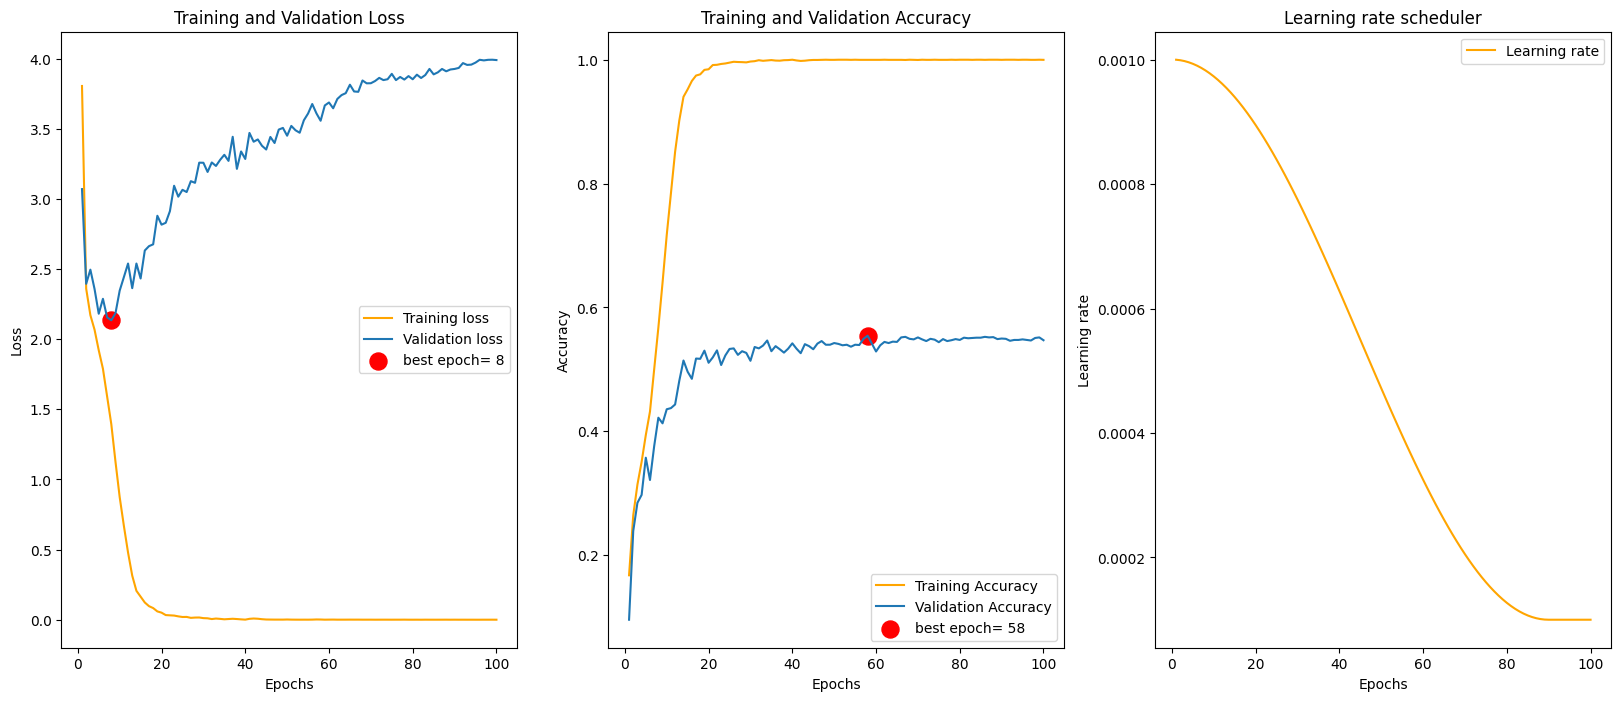

2024-12-16 13:43:28,914 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/logs/20241216-134328_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_8_cosine_decay_scheduler_accuracy_loss_acc_tr1.0_va0.4375_te0.65625_plots.png
2024-12-16 13:43:28,915 - INFO - Train loss: 4.1723194499354577e-07
Train Accuracy: 1.0
Validation loss: 5.6273298263549805
Validation Accuracy: 0.4375
Test Loss: 3.917297601699829
Test Accuracy: 0.65625


<Figure size 640x480 with 0 Axes>

In [23]:
# Plot
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc = training_exper_model_eff.history['accuracy']
tr_loss = training_exper_model_eff.history['loss']
val_acc = training_exper_model_eff.history['val_accuracy']
val_loss = training_exper_model_eff.history['val_loss']

learning_rate_logs = training_exper_model_eff.history['learning_rate']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

Epochs = [i + 1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs, tr_loss, 'orange', label='Training loss')
plt.plot(Epochs, val_loss, label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs, tr_acc, 'orange', label='Training Accuracy')
plt.plot(Epochs, val_acc, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs, learning_rate_logs, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.show()
plt.savefig(fig_name)
logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score[0]}"
                f"\nTrain Accuracy: {train_score[1]}"
                f"\nValidation loss: {valid_score[0]}"
                f"\nValidation Accuracy: {valid_score[1]}"
                f"\nTest Loss: {test_score[0]}"
                f"\nTest Accuracy: {test_score[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")






It can be seen from the training/validation loss chart that the model suffered heavy overfitting. The validation loss increased dramatically since epoch 08 whereas the training loss gradually decreased. It is worth noticing that the training/validation accuracy increased considerably well throughout training process. 

In [24]:
# Compute confusion matrix and plot figure

116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step


2024-12-16 13:43:36,542 - INFO -                    precision    recall  f1-score   support

american_football       0.68      0.60      0.64        96
         baseball       0.58      0.54      0.56       100
       basketball       0.62      0.47      0.53        86
    billiard_ball       0.61      0.58      0.59       162
     bowling_ball       0.44      0.43      0.44       111
     cricket_ball       0.62      0.59      0.61       146
         football       0.54      0.57      0.56       151
        golf_ball       0.43      0.47      0.45       138
      hockey_ball       0.49      0.45      0.47       133
      hockey_puck       0.52      0.54      0.53        98
       rugby_ball       0.55      0.62      0.58       124
      shuttlecock       0.45      0.52      0.48       108
table_tennis_ball       0.51      0.54      0.53       156
      tennis_ball       0.61      0.69      0.65       123
       volleyball       0.54      0.46      0.50       109

         accuracy    

[ 0  0  0 ...  8 14 10]
Confusion Matrix, Without Normalization
[[58  2  2  0  4  4  4  3  1  1  8  1  4  3  1]
 [ 3 54  4  1  4  2  6  5  2  1  3  6  4  2  3]
 [ 5  1 40  0  6  9  5  3  2  5  1  1  4  1  3]
 [ 0  1  3 94  9  3  3  6  8  5  6  1 13  4  6]
 [ 3  4  4  7 48  7  3  4  4  8  3  1  2  5  8]
 [ 9  1  2  7  5 86  3  7  5  2  2  1  4 11  1]
 [ 0  3  1  7  5  2 86  4  7  3  7  8  6  3  9]
 [ 1  4  1  3  3  4  8 65 10  3 13  8  8  6  1]
 [ 1  1  3 11  5 10  5  8 60  2  4  6  8  7  2]
 [ 1  3  0  9  5  1  3  4  2 53  3  1 10  1  2]
 [ 1  6  0  1  2  2 13  6  2  3 77  5  2  1  3]
 [ 0  3  1  5  1  2  4 12  3  3  3 56 10  4  1]
 [ 1  6  0  8  3  4  3  8  9  8  6 10 85  4  1]
 [ 1  2  0  1  4  1  2  9  4  1  1 10  0 85  2]
 [ 1  2  4  1  5  1 10  6  3  4  4  9  7  2 50]]


2024-12-16 13:43:37,039 - INFO - 20241216-134328: Saved plot to ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/logs/20241216-134328_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_8_cosine_decay_scheduler_accuracy_loss_acc_tr1.0_va0.4375_te0.65625_confusion_mat.png 



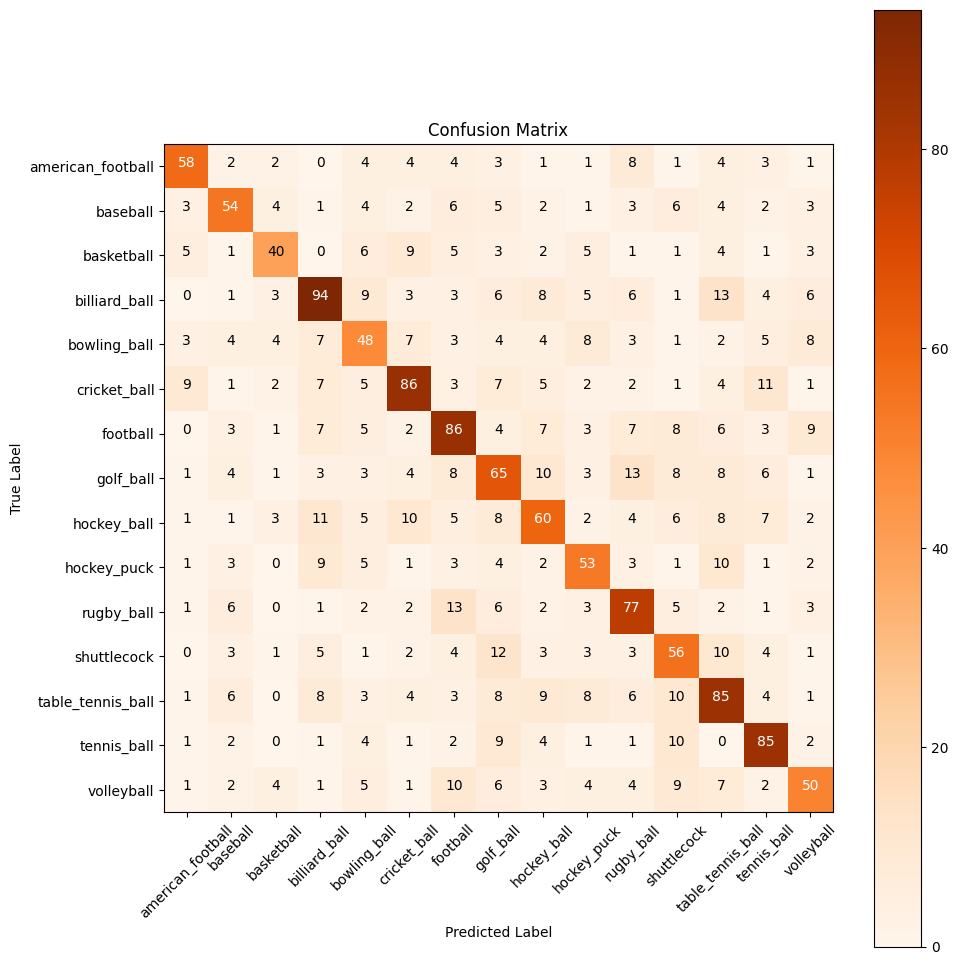

In [25]:
preds = model_new.predict(test_data)
y_pred = np.argmax(preds, axis=1)
print(y_pred)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data.classes, y_pred, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat.png")
# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=target_names, title='Confusion Matrix', figname=fig_name)

logger.info(f"{current_timestamp}: Saved plot to {fig_name} \n")


In [26]:
# Save everything
acc = test_score[1] * 100
save_path = checkpoints_dir

# Save history
history_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.npy"
np.save(history_filename, training_exper_model_eff.history)

logger.info(f'model training history was saved as {history_filename}')

# Save model
save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}.keras')
model_save_loc = os.path.join(save_path, save_id)
model_new.save(model_save_loc)
logger.info(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}-.weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model_new.save_weights(weights_save_loc)
logger.info(f'weights were saved as {weights_save_loc}')

elapsed_time = time.time() - start_time
logger.info(f"{current_timestamp}: Processing time: {elapsed_time} seconds.")
logger.info(time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))
logger.info(f"Finished!")


2024-12-16 13:43:37,347 - INFO - model training history was saved as ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/logs/ModelCNNExp1-20241216-134328.npy
2024-12-16 13:43:38,487 - INFO - model was saved as ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/checkpoints/20241216-130827___model_ModelCNNExp1_config_1_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-65.62.keras
2024-12-16 13:43:39,037 - INFO - weights were saved as ./experiments/ModelCNNExp1-20241216_V8RJZNCNG/checkpoints/20241216-130827___model_ModelCNNExp1_config_1_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-65.62-.weights.h5
2024-12-16 13:43:39,038 - INFO - 20241216-134328: Processing time: 2111.426019191742 seconds.
2024-12-16 13:43:39,039 - INFO - 00:35:11
2024-12-16 13:43:39,040 - INFO - Finished!


### 